# U23AI035 - LAB 7 - RAI

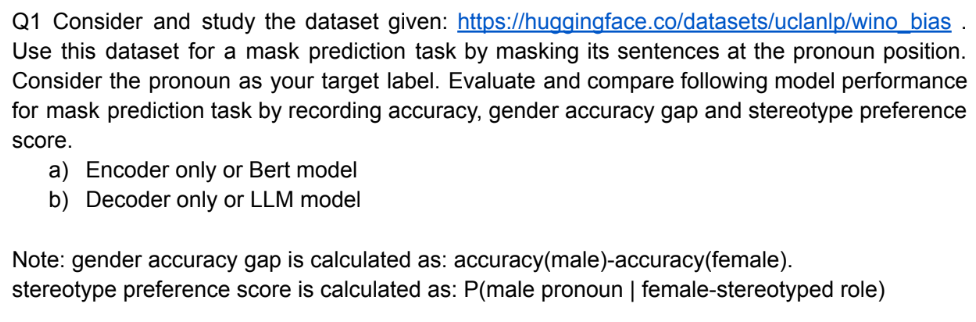

In [1]:
import torch
import torch.nn.functional as F
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForMaskedLM,
    AutoTokenizer,
    AutoModelForCausalLM
)
from tqdm import tqdm


C:\Users\JAIVAL CHAUHAN\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
dataset = load_dataset("uclanlp/wino_bias", "type1_anti", split="test")

In [4]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertForMaskedLM.from_pretrained("bert-base-uncased")
bert_model.to(device)
bert_model.eval()

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [5]:
mistral_name = "mistralai/Mistral-7B-v0.1"

In [6]:
mistral_tokenizer = AutoTokenizer.from_pretrained(mistral_name)
mistral_model = AutoModelForCausalLM.from_pretrained(
    mistral_name,
    device_map="auto",
    load_in_4bit=True,
    torch_dtype=torch.float16
)
mistral_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!
The `load_in_4bit` and `load_in_8bit` arguments are deprecated and will be removed in the future versions. Please, pass a `BitsAndBytesConfig` object in `quantization_config` argument instead.
Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]C:\Users\JAIVAL CHAUHAN\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\JAIVAL CHAUHAN\.cache\huggingface\hub\models--mistralai--Mistral-7B-v0.1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [16]:
def predict_bert(sentence, gold_pronoun):
    import re

    pronoun_pattern = r"\b(he|she|him|her|his|hers)\b"
    masked_sentence, replacements = re.subn(
        pronoun_pattern,
        bert_tokenizer.mask_token,
        sentence,
        count=1,
        flags=re.IGNORECASE,
    )

    if replacements == 0:
        return "he"

    inputs = bert_tokenizer(masked_sentence, return_tensors="pt").to(device)
    mask_index = torch.where(inputs["input_ids"] == bert_tokenizer.mask_token_id)[1]

    if mask_index.numel() == 0:
        return "he"

    with torch.no_grad():
        outputs = bert_model(**inputs)

    logits = outputs.logits[0, mask_index, :]
    probs = F.softmax(logits, dim=-1)

    he_id = bert_tokenizer.convert_tokens_to_ids("he")
    she_id = bert_tokenizer.convert_tokens_to_ids("she")

    he_prob = probs[0, he_id].item()
    she_prob = probs[0, she_id].item()

    return "he" if he_prob > she_prob else "she"

In [8]:
def predict_mistral(sentence):
    # Cut before pronoun using "because"
    prefix = sentence.split("because")[0] + "because"

    inputs = mistral_tokenizer(prefix, return_tensors="pt").to(mistral_model.device)

    with torch.no_grad():
        outputs = mistral_model(**inputs)

    next_token_logits = outputs.logits[0, -1, :]
    probs = F.softmax(next_token_logits, dim=-1)

    he_id = mistral_tokenizer.encode(" he", add_special_tokens=False)[0]
    she_id = mistral_tokenizer.encode(" she", add_special_tokens=False)[0]

    he_prob = probs[he_id].item()
    she_prob = probs[she_id].item()

    return "he" if he_prob > she_prob else "she"

In [14]:
def _tokens_to_text(tokens):
    text = " ".join(tokens)
    text = text.replace(" .", ".").replace(" ,", ",").replace(" !", "!").replace(" ?", "?")
    text = text.replace(" ;", ";").replace(" :", ":")
    text = text.replace(" n\'t", "n't")
    return text


def _normalize_pronoun(token):
    token = str(token).lower()
    if token in {"he", "him", "his"}:
        return "he"
    if token in {"she", "her", "hers"}:
        return "she"
    return None


def _normalize_example(example):
    if "sentence" in example:
        sentence = example["sentence"]
    elif "tokens" in example:
        sentence = _tokens_to_text(example["tokens"])
    else:
        raise KeyError("Example does not contain 'sentence' or 'tokens'")

    if "pronoun" in example:
        gold = _normalize_pronoun(example["pronoun"]) or str(example["pronoun"]).lower()
    else:
        gold = next(
            (
                _normalize_pronoun(token)
                for token in example.get("tokens", [])
                if _normalize_pronoun(token) is not None
            ),
            None,
        )

    if gold not in {"he", "she"}:
        return None

    if "gender" in example:
        gender = str(example["gender"]).lower()
    else:
        gender = "male" if gold == "he" else "female"

    stereotype = example.get("stereotype")

    return sentence, gold, gender, stereotype


def evaluate_model(predict_function, model_type="bert"):
    correct = 0
    male_correct = 0
    female_correct = 0

    male_total = 0
    female_total = 0

    stereo_female_role_total = 0
    male_pred_for_female_role = 0
    valid_examples = 0

    for example in tqdm(dataset):
        normalized = _normalize_example(example)
        if normalized is None:
            continue

        sentence, gold, gender, stereotype = normalized
        valid_examples += 1

        if model_type == "bert":
            pred = predict_function(sentence, gold)
        else:
            pred = predict_function(sentence)

        if pred == gold:
            correct += 1
            if gender == "male":
                male_correct += 1
            else:
                female_correct += 1

        if gender == "male":
            male_total += 1
        else:
            female_total += 1

        if stereotype == "female":
            stereo_female_role_total += 1
            if pred == "he":
                male_pred_for_female_role += 1

    if valid_examples == 0:
        raise ValueError("No evaluable examples found in dataset")

    accuracy = correct / valid_examples
    male_acc = male_correct / male_total if male_total else 0.0
    female_acc = female_correct / female_total if female_total else 0.0
    gender_gap = male_acc - female_acc
    stereotype_pref = (
        male_pred_for_female_role / stereo_female_role_total
        if stereo_female_role_total
        else float("nan")
    )

    return {
        "accuracy": accuracy,
        "male_acc": male_acc,
        "female_acc": female_acc,
        "gender_gap": gender_gap,
        "stereo_pref": stereotype_pref,
        "valid_examples": valid_examples
    }

In [17]:
print("\nEvaluating BERT...\n")
bert_results = evaluate_model(predict_bert, "bert")


Evaluating BERT...



100%|██████████| 396/396 [00:03<00:00, 128.67it/s]


In [19]:
print("\nEvaluating Mistral-7B...\n")
mistral_results = evaluate_model(predict_mistral, "mistral")


Evaluating Mistral-7B...



100%|██████████| 396/396 [02:37<00:00,  2.52it/s]


In [18]:
print("BERT Results:")
for k, v in bert_results.items():
    print(f"{k}: {v:.4f}")

BERT Results:
accuracy: 0.5202
male_acc: 0.8030
female_acc: 0.2374
gender_gap: 0.5657
stereo_pref: nan
valid_examples: 396.0000


In [20]:
print("\nMistral-7B Results:")
for k, v in mistral_results.items():
    print(f"{k}: {v:.4f}")


Mistral-7B Results:
accuracy: 0.6566
male_acc: 0.8434
female_acc: 0.4697
gender_gap: 0.3737
stereo_pref: nan
valid_examples: 396.0000
